### DecisionTree(의사결정나무)
- parameter
    - criterion
        - 분류
            - 기본값 : gini
            - entropy : 성능 항상, 속도가 느려진다.
            - log_loss : 확률적 분류
        - 회귀
            - 기본값 : squared_error(MSE)
            - absolute_error : MAE
            - friedman_mas : 분산 감소 기반
    - spliter
        - 기본값 : best
        - 분할 시 featuer(컬럼) 선택 방식
        - best
            - 가장 좋은 feature를 선택
        - random
            - 무작위 feature를 선택(다양성을 올리기 위함 / 여러 학습을 통한 예측(앙상블))
    - max_depth
        - 기본값 : None
        - 트리의 최대 깊이 제한 
        - None인 경우 Leaf까지 계속 분할 -> 과적합 위험
    - min_samples_split
        - 기본값 : 2
        - 노드를 분할하기 위한 최소한의 샘플 개수를 지정
    - min_sample_leaf
        - 기본값 : 1
        - Leaf 노드가 되기 위한 최소 샘플 수
    - max_features
        - 기본값 : None
        - 최적으로 분할 시 고려할 feature 개수
        - None
            - 모든 feature 사용
        - sqrt
            - feature의 개수에서 루트를 입혀서 사용
        - log2
            - feature의 개수에서 log2를 입혀서 사용
        - 숫자형태로 고정돤 값을 사용 가능
    - min_impurity_decrease
        - 기본값 : 0.0
        - 불순도 감소량이 해당 매개변수의 인자값 이상일 때만 데이터 분할 수정
    - ccp_alpha
        - 기본값 : 0.0
        - 비용-복잡도 가지치기 매개변수
        - 값이 커지는 경우 트리의 단순화
- 속성
    - tree_
        - 트리 구조에 대한 상세 객체
    - class_
        - 분류 본체에서 클랙스의 목록(정답 리스트)
    - n_classes_
        - 클래스의 개수
    - n_features_in_
        - 입력되는 데이터의 feature 개수
    - feature_importance_
        - 각 feature들의 중요도(중요도들의 합은 1)
- 메서드
    - fit()
        - 모델 학습
    - predict()
        - 학습된 모델로 예측
    - score()
        - 분류에서는 정확도
        - 회귀에서는 R2 Score
    - predict_proba()
        - 분류에서만 사용하는 함수
        - 각 클레스별 예측 확률

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, precision_score


In [141]:
iris=pd.read_csv('../csv/iris.csv')

In [142]:
X_train,X_test,y_train,y_test=train_test_split(
    iris.drop('species',axis=1),
    iris['species'],
    test_size=0.2,
    random_state=42,
    stratify=iris['species']
)

In [143]:
#max_depth 5,3,1을 기준으로 3개의 모델을 생성
#score(X_train,y_train)함수를 이용해서 학습된 데이터에서 정확도를 확인 
#X_test를 이용하여 예측 -> f1_score를 이용하여 모델의 성능을 확인
dct1=DecisionTreeClassifier(
    max_depth=5, random_state=42
)
dct2=DecisionTreeClassifier(
    max_depth=3, random_state=42
)
dct3=DecisionTreeClassifier(
    max_depth=1, random_state=42
)

In [144]:
dct1.fit(X_train,y_train)
dct2.fit(X_train,y_train)
dct3.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [145]:
#각각의 score() 확인
print(dct1.score(X_train,y_train))
print(dct2.score(X_train,y_train))
print(dct3.score(X_train,y_train))

1.0
0.9833333333333333
0.6666666666666666


In [146]:
pred1=dct1.predict(X_test)
pred2=dct2.predict(X_test)
pred3=dct3.predict(X_test)

In [147]:
print(f1_score(y_test,pred1,average='micro'))
print(f1_score(y_test,pred2,average='micro'))
print(f1_score(y_test,pred3,average='micro'))

0.9333333333333333
0.9666666666666667
0.6666666666666666


In [ ]:
dct1.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [149]:
#dct2,dct3 plot_Tree를 이용히야 시각화 계산
feature_names = X_train.columns
class_names=y_train.unique()

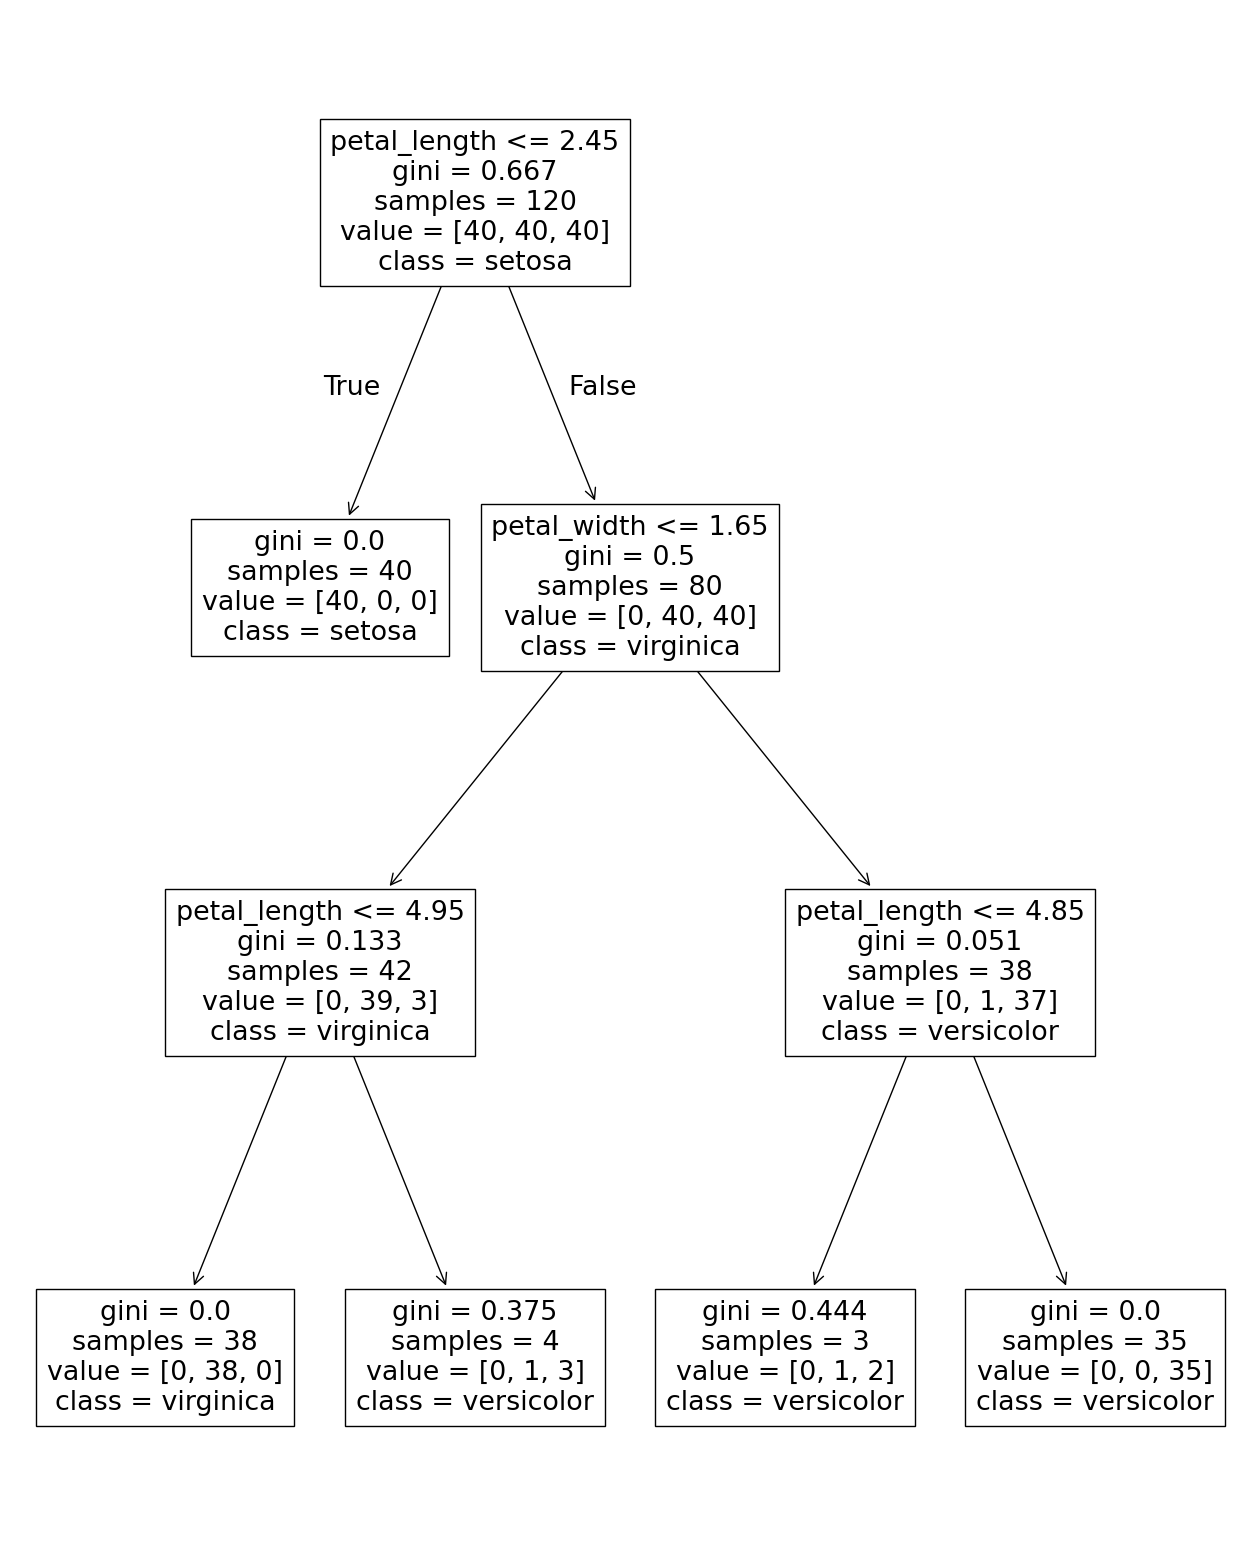

In [150]:
plt.figure(figsize=(16,20))
plot_tree(
    dct2,
    feature_names=feature_names,
    class_names=class_names,

)

plt.show()

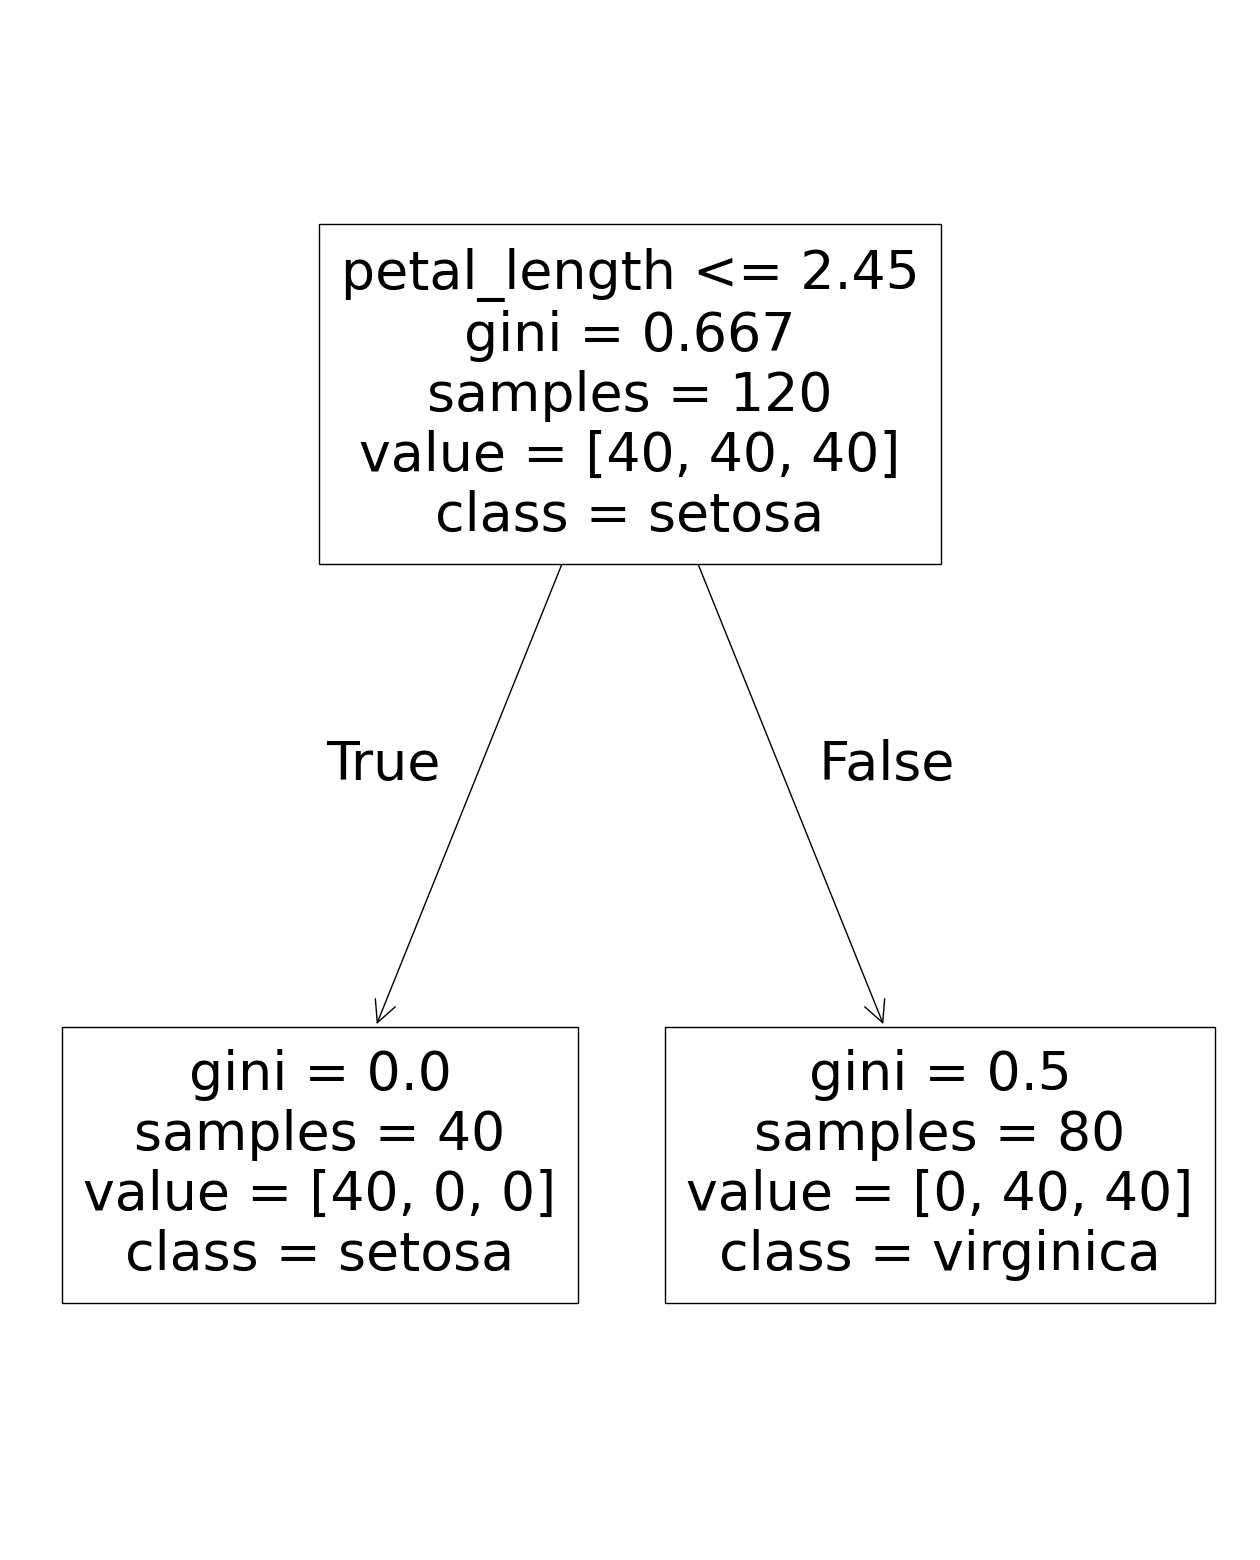

In [151]:
plt.figure(figsize=(16,20))
plot_tree(
    dct3,
    feature_names=feature_names,
    class_names=class_names,

)

plt.show()

In [ ]:
pred=dct1.predict(X_test)
print(f1_score(y_test,pred, average='micro'))

0.9333333333333333


In [153]:
#data폴더에서 diabetes.csv
df=pd.read_csv('../data/diabetes.csv')

In [154]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


- Pregnanccies : 임신 횟수
- Glucose : 혈당
- BloodPressure : 이완기 혈압
- SkinThickness : 삼두근 피부 주름 두께,
- Insulin : 인슐린
- BMI : 체질량 지수
- Diabetes-PedigreeFunction : 당뇨 내력
- Age : 나이
- Outcome : 클래스 결정값(유 / 무)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [156]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [157]:
flag=df['Glucose']==0
df.loc[flag,]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [158]:
flag=df['BloodPressure']==0
df.loc[flag,]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1
222,7,119,0,0,0,25.2,0.209,37,0
261,3,141,0,0,0,30.0,0.761,27,1


In [159]:
df['Outcome']

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [160]:
#독립변수, 종속뱐수 train, test로 분할
X_train,X_test,y_train,y_test=train_test_split(
    df.drop('Outcome',axis=1),
    df['Outcome'],
    test_size=0.3,
    stratify=df['Outcome'],
    random_state=42
)

In [161]:
#깊이가 3, 5, 7
dct_3=DecisionTreeClassifier(max_depth=3, random_state=42)
dct_5=DecisionTreeClassifier(max_depth=5, random_state=42)
dct_7=DecisionTreeClassifier(max_depth=7, random_state=42)

In [162]:
dct_3.fit(X_train,y_train)
dct_5.fit(X_train,y_train)
dct_7.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [163]:
print(
    dct_3.score(X_test,y_test),
    dct_5.score(X_test,y_test),
    dct_7.score(X_test,y_test)
)

0.7272727272727273 0.7662337662337663 0.7922077922077922


In [164]:
dct_9=DecisionTreeClassifier(max_depth=9, random_state=42)
dct_9.fit(X_train,y_train)
print(
    dct_9.score(X_test,y_test))

0.7575757575757576


In [165]:
pred=dct_7.predict(X_test)

In [166]:
#혼동 행렬
cm=confusion_matrix(y_test,pred)
print(cm)

[[135  15]
 [ 33  48]]


In [167]:
acc=accuracy_score(y_test,pred)
prc=precision_score(y_test,pred)
recall=recall_score(y_test,pred)
f1=f1_score(y_test,pred)

In [168]:
print('정확도',acc)
print('정밀도',prc)
print('재현율',recall)
print('F1 Score',f1)

정확도 0.7922077922077922
정밀도 0.7619047619047619
재현율 0.5925925925925926
F1 Score 0.6666666666666666


In [169]:
#feature 중요도 확인
dct_7.feature_importances_

array([0.05298908, 0.37361116, 0.0691613 , 0.01889507, 0.01781288,
       0.18272839, 0.16217763, 0.12262449])

### 모델의 성능을 높여보자
1. 혈당, 렬압, BMI 데이터 컬럼에서 0인 데이터를 해당 컬럼의 평균으로 값을 대체
2. 스케일링을 사용해보자.
    - 원본 데이터를 사용하여 모델 성능을 확인
    - 스케일링 데이터를 사용하여 모델의 성능을 확인

In [170]:
#혈당 데이터의 0을 제외한 값들의 평균
mean_value=df.loc[~flag,'Glucose'].mean()

In [171]:
#혈당이 0인 데이터에 평균을 대입
df.loc[flag,'Glucose']=mean_value

C:\Users\user\AppData\Local\Temp\ipykernel_808\3550302650.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.04229195088676' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[flag,'Glucose']=mean_value


In [172]:
import numpy as np

In [173]:
#BloodPressure 컬럼에서 0인 데이터를 결측치로 대체
df['BloodPressure'].mean()

np.float64(69.10546875)

In [175]:
df.loc[flag,'BloodPressure']==np.nan

7      False
15     False
49     False
60     False
78     False
81     False
172    False
193    False
222    False
261    False
266    False
269    False
300    False
332    False
336    False
347    False
357    False
426    False
430    False
435    False
453    False
468    False
484    False
494    False
522    False
533    False
535    False
589    False
601    False
604    False
619    False
643    False
697    False
703    False
706    False
Name: BloodPressure, dtype: bool

In [176]:
df['BloodPressure'].mean()

np.float64(69.10546875)

In [178]:
#'BloodPressure'컬럼에서 결측치를 채워준더.
df['BloodPRessure']=df['BloodPressure'].fillna(mean_value)

In [179]:
#BMI의 값에서 0은 최빗값으로 채운다.
value3=df['BMI'].value_counts().index[0]

In [181]:
df.loc[flag,'BMI']=value3

In [182]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BloodPRessure
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.042292,69.105469,20.536458,79.799479,32.279427,0.471876,33.240885,0.348958,69.105469
std,3.369578,31.437148,19.355807,15.952218,115.244002,7.103957,0.331329,11.760232,0.476951,19.355807
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000,0.000000
25%,1.000000,100.000000,62.000000,0.000000,0.000000,27.600000,0.243750,24.000000,0.000000,62.000000
50%,3.000000,119.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000,72.000000
75%,6.000000,139.000000,80.000000,32.000000,127.250000,36.325000,0.626250,41.000000,1.000000,80.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000,122.000000


In [183]:
def score_print(y,pred):
    print(accuracy_score,(y,pred))
    print(precision_score,(y,pred))
    print(recall_score,(y,pred))
    print(f1_score,(y,pred))

In [189]:
#수정한 데이터를 이용하여 깊이가 7인 의시결정나무에 학습 및 예측을 하명 정확도, 정밀도, 재현율, f1-score 확인
X_train,X_test,y_train,y_test=train_test_split(
    df.drop('Outcome',axis=1),
    df['Outcome'],
    test_size=0.3,
    stratify=df['Outcome'],
    random_state=42
)

# dct7=DecisionTreeClassifier(
    # max_depth=7,
    # random_state=42
# )
# 
dct_7.fit(X_train,y_train)
pred=dct_7.predict(X_test)

score_print(y_test,pred)

<function accuracy_score at 0x000001B2B612AB90> (730    1
198    1
24     1
417    1
387    1
      ..
94     0
437    0
86     0
221    1
19     1
Name: Outcome, Length: 231, dtype: int64, array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0]))
<function precision_score at 0x000001B

In [190]:
#StandardScaler를 이용하여 스케일링 후 깊이 7 의사결정 나무 평가지표 확인
from sklearn.preprocessing import StandardScaler

stdScaler=StandardScaler()

In [193]:
X_train_sc=stdScaler.fit_transform(X_train)
X_test_sc=stdScaler.transform(X_test)

In [194]:
dct_7.fit(X_train_sc,y_train)
pred2=dct_7.predict(X_test_sc)

score_print(y_test,pred)
score_print(y_test,pred2)

<function accuracy_score at 0x000001B2B612AB90> (730    1
198    1
24     1
417    1
387    1
      ..
94     0
437    0
86     0
221    1
19     1
Name: Outcome, Length: 231, dtype: int64, array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0]))
<function precision_score at 0x000001B